# Unified WSSS: DINOv3 + SAM Distillation

This notebook trains a weakly supervised segmentation pipeline using cached DINOv3 features and SAM-generated pseudo masks.

In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dino_model = torch.hub.load(
    "./dinov3",
    "dinov3_vitl16",
    source="local",
    weights="dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth",
).to(device)
dino_model.eval()

sam2_model = build_sam2("configs/sam2.1/sam2.1_hiera_s.yaml", "./sam2.1_hiera_small.pt", device=device)
predictor = SAM2ImagePredictor(sam2_model)
print("Models loaded.")

Using device: cuda
Models loaded.


### Data Loading

We use PASCAL VOC and derive image-level tags from the segmentation masks.

In [2]:
import numpy as np
import os

VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog',
    'horse', 'motorbike', 'person', 'pottedplant', 'sheep',
    'sofa', 'train', 'tvmonitor'
]

def make_transform(resize_size: int = 448):
    return v2.Compose([
        v2.ToImage(),
        v2.Resize((resize_size, resize_size), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])

transform = make_transform()

class WSSSDataset(torch.utils.data.Dataset):
    def __init__(self, voc_dataset, transform):
        self.voc = voc_dataset
        self.transform = transform

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]
        img_t = self.transform(img)
        mask_t = torch.tensor(np.array(mask), dtype=torch.long)
        unique_classes = torch.unique(mask_t)
        unique_classes = unique_classes[(unique_classes != 0) & (unique_classes != 255)]

        label_vec = torch.zeros(20, dtype=torch.float32)
        if len(unique_classes) > 0:
            label_vec[unique_classes - 1] = 1.0

        return idx, img_t, label_vec

def wsss_collate_fn(batch):
    indices = torch.tensor([b[0] for b in batch], dtype=torch.long)
    images = torch.stack([b[1] for b in batch])
    labels = torch.stack([b[2] for b in batch])
    return indices, images, labels

voc_raw = torchvision.datasets.VOCSegmentation(
    root="./data",
    year="2012",
    image_set="train",
    download=False,
)
voc_segmentation = WSSSDataset(voc_raw, transform)

batch_size = 16
num_workers = min(4, os.cpu_count() or 1)

seq_dataloader = DataLoader(
    voc_segmentation,
    batch_size=batch_size,
    collate_fn=wsss_collate_fn,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)
dataloader = DataLoader(
    voc_segmentation,
    batch_size=batch_size,
    collate_fn=wsss_collate_fn,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

print(f"VOC train set: {len(voc_segmentation)} images across {num_workers} workers.")

VOC train set: 1464 images across 4 workers.


### Segmenter

The segmenter maps cached DINO patch tokens to dense class logits.

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class UnifiedWSSSSegmenter(nn.Module):
    def __init__(self, in_channels=1024, num_classes=20):
        super().__init__()
        self.in_channels = in_channels
        self.decoder = nn.Sequential(
            nn.Conv2d(in_channels, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(512, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1),
        )

    def forward(self, patch_tokens, grid_size, target_size):
        x = patch_tokens.permute(0, 2, 1).reshape(-1, self.in_channels, *grid_size)
        logits = self.decoder(x)
        dense_logits = F.interpolate(logits, size=target_size, mode='bilinear', align_corners=False)
        image_level_logits = dense_logits.amax(dim=(2, 3))
        return image_level_logits, dense_logits

### Training

The model is trained with image-level tags and SAM-generated pseudo masks.

In [4]:
from tqdm.notebook import tqdm

print("Caching DINO tokens...")
num_images = len(voc_segmentation)
dino_cache_tensor = torch.zeros((num_images, 784, 1024), dtype=torch.float16, device=device)

dino_model.eval()
with torch.inference_mode():
    for indices, images, _ in tqdm(seq_dataloader, desc="Caching DINO Tokens"):
        images = images.to(device, non_blocking=True)
        features = dino_model.forward_features(images)
        patch_tokens = features['x_norm_patchtokens'].half()

        for i, idx in enumerate(indices):
            dino_cache_tensor[idx] = patch_tokens[i]

mem_usage_gb = dino_cache_tensor.element_size() * dino_cache_tensor.nelement() / (1024**3)
print(f"Cached DINO tokens in {mem_usage_gb:.2f} GB of GPU memory.")

Caching DINO tokens...


Caching DINO Tokens:   0%|          | 0/92 [00:00<?, ?it/s]

Cached DINO tokens in 2.19 GB of GPU memory.


Loading checkpoint from wsss_checkpoint.pth...
Resuming from epoch 30
Starting unified distillation.


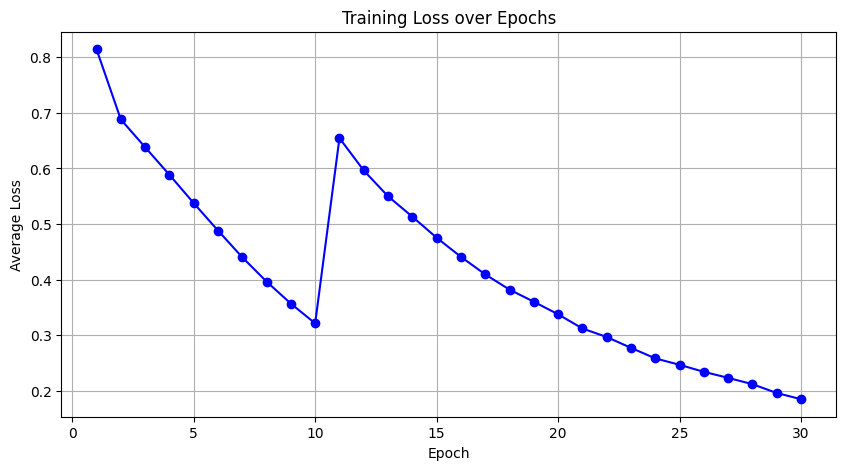

In [ ]:
import os
import random
from typing import List, Tuple, Callable, Any

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader

# ==========================================
# Parameters & Configuration
# ==========================================
NUM_EPOCHS: int = 30
BURN_IN_EPOCHS: int = 10
LEARNING_RATE: float = 1e-4
CHECKPOINT_PATH: str = "wsss_checkpoint.pth"
DEVICE: torch.device = device 

# Structural constants extracted from the code
NUM_CLASSES: int = 20
SAM_IMG_SIZE: int = 1024       # SAM expects 1024x1024 input features/images
CAM_THRESHOLD: float = 0.4     # Threshold for CAM to determine active mask box

# ==========================================
# Loss Functions
# ==========================================
def seg_bce_dice_loss(preds: torch.Tensor, targets: torch.Tensor, dice_weight: float = 0.5, dice_smoothing: float = 1.0) -> torch.Tensor:
    """
    Calculates combined BCE and Dice loss directly (Truth vs Output).
    Expected shape for preds and targets: (N, H, W) where N is active classes in batch.
    """
    bce = F.binary_cross_entropy_with_logits(preds, targets)

    # DICE loss
    probs = torch.sigmoid(preds)
    intersection = (probs * targets).sum()
    union = probs.sum() + targets.sum()
    dice = 1 - (2.0 * intersection + dice_smoothing) / (union + dice_smoothing)

    return bce + (dice_weight * dice)

# Interchangeable loss aliases
cls_loss_fn = nn.BCEWithLogitsLoss()
seg_loss_fn = seg_bce_dice_loss

# ==========================================
# Helper Functions
# ==========================================
@torch.no_grad()
def generate_sam_pseudo_labels(
    images: torch.Tensor, 
    dense_logits: torch.Tensor, 
    image_level_labels: torch.Tensor, 
    predictor: Any, 
    device: torch.device,
    sam_img_size: int = 1024,
    cam_threshold: float = 0.4
) -> torch.Tensor:
    """Generates pseudo labels using SAM given predicted CAMs."""
    B, _, H, W = images.shape
    pseudo_labels_batch = torch.zeros((B, NUM_CLASSES, H, W), dtype=torch.float32, device=device)
    
    images_sam = F.interpolate(images, size=(sam_img_size, sam_img_size), mode='bilinear', align_corners=False)
    backbone_out = predictor.model.forward_image(images_sam)
    _, vision_feats, _, _ = predictor.model._prepare_backbone_features(backbone_out)
    
    if predictor.model.directly_add_no_mem_embed:
        vision_feats[-1] = vision_feats[-1] + predictor.model.no_mem_embed

    feats = [
        feat.permute(1, 2, 0).view(B, -1, *feat_size)
        for feat, feat_size in zip(vision_feats[::-1], predictor._bb_feat_sizes[::-1])
    ][::-1]

    predictor._features = {"image_embed": feats[-1], "high_res_feats": feats[:-1]}
    predictor._is_image_set = True
    predictor._is_batch = True
    predictor._orig_hw = [(H, W)] * B

    for b_idx in range(B):
        active_classes = torch.where(image_level_labels[b_idx] > 0)[0]
        if len(active_classes) == 0:
            continue

        C_num = len(active_classes)
        cam_active = dense_logits[b_idx, active_classes].detach()
        cam_flat = cam_active.view(C_num, -1)
        cam_min = cam_flat.min(dim=1, keepdim=True)[0]
        cam_max = cam_flat.max(dim=1, keepdim=True)[0]
        cam_norm = (cam_flat - cam_min) / (cam_max - cam_min + 1e-8)

        max_flat = cam_norm.argmax(dim=1)
        max_y = torch.div(max_flat, W, rounding_mode='trunc').unsqueeze(-1).unsqueeze(-1)
        max_x = (max_flat % W).unsqueeze(-1).unsqueeze(-1)

        scaled_x = max_x.float() * (sam_img_size / W)
        scaled_y = max_y.float() * (sam_img_size / H)

        cam_norm_2d = cam_norm.view(C_num, H, W)
        mask_bool = cam_norm_2d > cam_threshold

        y_idx = torch.arange(H, device=device).view(1, H, 1).expand(C_num, H, W)
        x_idx = torch.arange(W, device=device).view(1, 1, W).expand(C_num, H, W)

        y_min = torch.where(mask_bool, y_idx, H).amin(dim=(1, 2))
        y_max = torch.where(mask_bool, y_idx, -1).amax(dim=(1, 2))
        x_min = torch.where(mask_bool, x_idx, W).amin(dim=(1, 2))
        x_max = torch.where(mask_bool, x_idx, -1).amax(dim=(1, 2))

        valid_box = y_min <= y_max

        box_x_min = torch.clamp(x_min.float() * (sam_img_size / W), 0, sam_img_size).unsqueeze(-1)
        box_y_min = torch.clamp(y_min.float() * (sam_img_size / H), 0, sam_img_size).unsqueeze(-1)
        box_x_max = torch.clamp(x_max.float() * (sam_img_size / W), 0, sam_img_size).unsqueeze(-1)
        box_y_max = torch.clamp(y_max.float() * (sam_img_size / H), 0, sam_img_size).unsqueeze(-1)
        boxes_cuda = torch.cat([box_x_min, box_y_min, box_x_max, box_y_max], dim=-1)

        pt_coords_cuda = torch.cat([scaled_x, scaled_y], dim=-1)
        pt_labels_cuda = torch.ones(C_num, 1, dtype=torch.int, device=device)

        for c in range(C_num):
            c_boxes = boxes_cuda[c:c+1] if valid_box[c] else None
            masks, _, _ = predictor._predict(
                point_coords=pt_coords_cuda[c:c+1],
                point_labels=pt_labels_cuda[c:c+1],
                boxes=c_boxes,
                multimask_output=False,
                return_logits=False,
                img_idx=b_idx,
            )
            pseudo_labels_batch[b_idx, active_classes[c]] = masks.squeeze(0).squeeze(0).float()
            
    return pseudo_labels_batch

def train_one_epoch(
    epoch: int, 
    dataloader: DataLoader, 
    model: nn.Module, 
    optimizer: optim.Optimizer, 
    cls_loss_fn: Callable, 
    seg_loss_fn: Callable, 
    predictor: Any, 
    dino_cache: torch.Tensor, 
    device: torch.device, 
    is_burn_in: bool
) -> float:
    model.train()
    epoch_total_loss = 0.0
    num_batches = 0

    desc = f"Epoch {epoch + 1} Distillation {'(Burn-in)' if is_burn_in else ''}"
    for indices, images, image_level_labels in tqdm(dataloader, desc=desc):
        images = images.to(device, non_blocking=True)
        image_level_labels = image_level_labels.to(device, non_blocking=True)
        B, _, H, W = images.shape

        optimizer.zero_grad(set_to_none=True)

        patch_tokens = dino_cache[indices].float()
        grid_dim = int(patch_tokens.shape[1] ** 0.5)
        
        # Forward pass
        img_logits, dense_logits = model(
            patch_tokens,
            grid_size=(grid_dim, grid_dim),
            target_size=(H, W),
        )
        
        # 1. Classification loss (Image level)
        loss_cls = cls_loss_fn(img_logits, image_level_labels)
        total_loss = loss_cls

        # 2. Segmentation Distillation loss
        if not is_burn_in:
            pseudo_labels = generate_sam_pseudo_labels(
                images, dense_logits, image_level_labels, predictor, device,
                sam_img_size=SAM_IMG_SIZE, cam_threshold=CAM_THRESHOLD
            )
            
            # Decouple the segmentation loss map: only process loss on active classes directly (Truth vs Output)
            b_idx, c_idx = torch.where(image_level_labels > 0)
            if len(b_idx) > 0:
                active_preds = dense_logits[b_idx, c_idx]
                active_targets = pseudo_labels[b_idx, c_idx]
                loss_seg = seg_loss_fn(active_preds, active_targets)
                total_loss += loss_seg

        total_loss.backward()
        optimizer.step()

        epoch_total_loss += total_loss.item()
        num_batches += 1

    return epoch_total_loss / max(1, num_batches)

def plot_losses(losses: List[float], save_path: str = 'loss_curve.png') -> None:
    if not losses:
        return
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='b')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()

# ==========================================
# Main Execution
# ==========================================
model = UnifiedWSSSSegmenter(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

start_epoch = 0
epoch_losses = []

if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    epoch_losses = checkpoint.get('epoch_losses', [])
    print(f"Resuming from epoch {start_epoch}")

print("Starting unified distillation.")

for epoch in range(start_epoch, NUM_EPOCHS):
    is_burn_in = epoch < BURN_IN_EPOCHS
    
    avg_loss = train_one_epoch(
        epoch=epoch,
        dataloader=dataloader,
        model=model,
        optimizer=optimizer,
        cls_loss_fn=cls_loss_fn,
        seg_loss_fn=seg_loss_fn,
        predictor=predictor,
        dino_cache=dino_cache_tensor,
        device=DEVICE,
        is_burn_in=is_burn_in
    )
    
    epoch_losses.append(avg_loss)

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch_losses': epoch_losses,
    }, CHECKPOINT_PATH)

plot_losses(epoch_losses)

In [ ]:
print("Loading VOC 2012 validation set...")
voc_val_raw = torchvision.datasets.VOCSegmentation(
    root="./data",
    year="2012",
    image_set="val",
    download=False,
)

class ValDataset(torch.utils.data.Dataset):
    def __init__(self, voc_dataset, transform):
        self.voc = voc_dataset
        self.transform = transform

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]
        img_t = self.transform(img)
        mask_t = torch.tensor(np.array(mask), dtype=torch.long)
        return img_t, mask_t

def val_collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = [b[1] for b in batch]
    return images, masks

val_dataset = ValDataset(voc_val_raw, transform)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=16,
    collate_fn=val_collate_fn,
    shuffle=False,
    num_workers=min(4, os.cpu_count() or 1),
    pin_memory=True,
)

def calculate_miou(model, dino_model, dataloader, device):
    model.eval()
    dino_model.eval()

    intersection = torch.zeros(21, device=device)
    union = torch.zeros(21, device=device)

    print("Evaluating validation mIoU...")
    with torch.inference_mode():
        for images, masks in tqdm(dataloader):
            images = images.to(device, non_blocking=True)
            features = dino_model.forward_features(images)
            patch_tokens = features['x_norm_patchtokens'].float()

            grid_dim = int(patch_tokens.shape[1] ** 0.5)
            _, dense_logits = model(
                patch_tokens,
                grid_size=(grid_dim, grid_dim),
                target_size=(images.shape[2], images.shape[3]),
            )

            for b, mask in enumerate(masks):
                mask_t = mask.to(device)
                H, W = mask_t.shape

                img_logits = F.interpolate(
                    dense_logits[b].unsqueeze(0),
                    size=(H, W),
                    mode='bilinear',
                    align_corners=False,
                )[0]
                pred_probs = torch.sigmoid(img_logits)
                bg_prob = torch.full((1, H, W), 0.5, device=device)
                full_probs = torch.cat([bg_prob, pred_probs], dim=0)
                preds = full_probs.argmax(dim=0)

                valid = mask_t != 255
                for c in range(21):
                    pred_c = (preds == c) & valid
                    target_c = (mask_t == c) & valid
                    intersection[c] += (pred_c & target_c).sum()
                    union[c] += (pred_c | target_c).sum()

    iou = intersection / union.clamp(min=1e-8)

    print("Validation results")
    for c, name in enumerate(['background'] + VOC_CLASSES):
        if union[c] > 0:
            print(f"{name.ljust(15)}: {iou[c].item():.4f}")

    miou = iou[union > 0].mean().item()
    print(f"mIoU: {miou:.4f}")

    return miou

val_miou = calculate_miou(model, dino_model, val_dataloader, device)

Loading VOC 2012 validation set...
Evaluating validation mIoU...


  0%|          | 0/91 [00:00<?, ?it/s]

Validation results
background     : 0.9002
aeroplane      : 0.8989
bicycle        : 0.4139
bird           : 0.9073
boat           : 0.8118
bottle         : 0.7584
bus            : 0.9542
car            : 0.8893
cat            : 0.9663
chair          : 0.2742
cow            : 0.0037
diningtable    : 0.2018
dog            : 0.9519
horse          : 0.8377
motorbike      : 0.8645
person         : 0.6769
pottedplant    : 0.3115
sheep          : 0.8071
sofa           : 0.6338
train          : 0.9372
tvmonitor      : 0.7824
mIoU: 0.7039


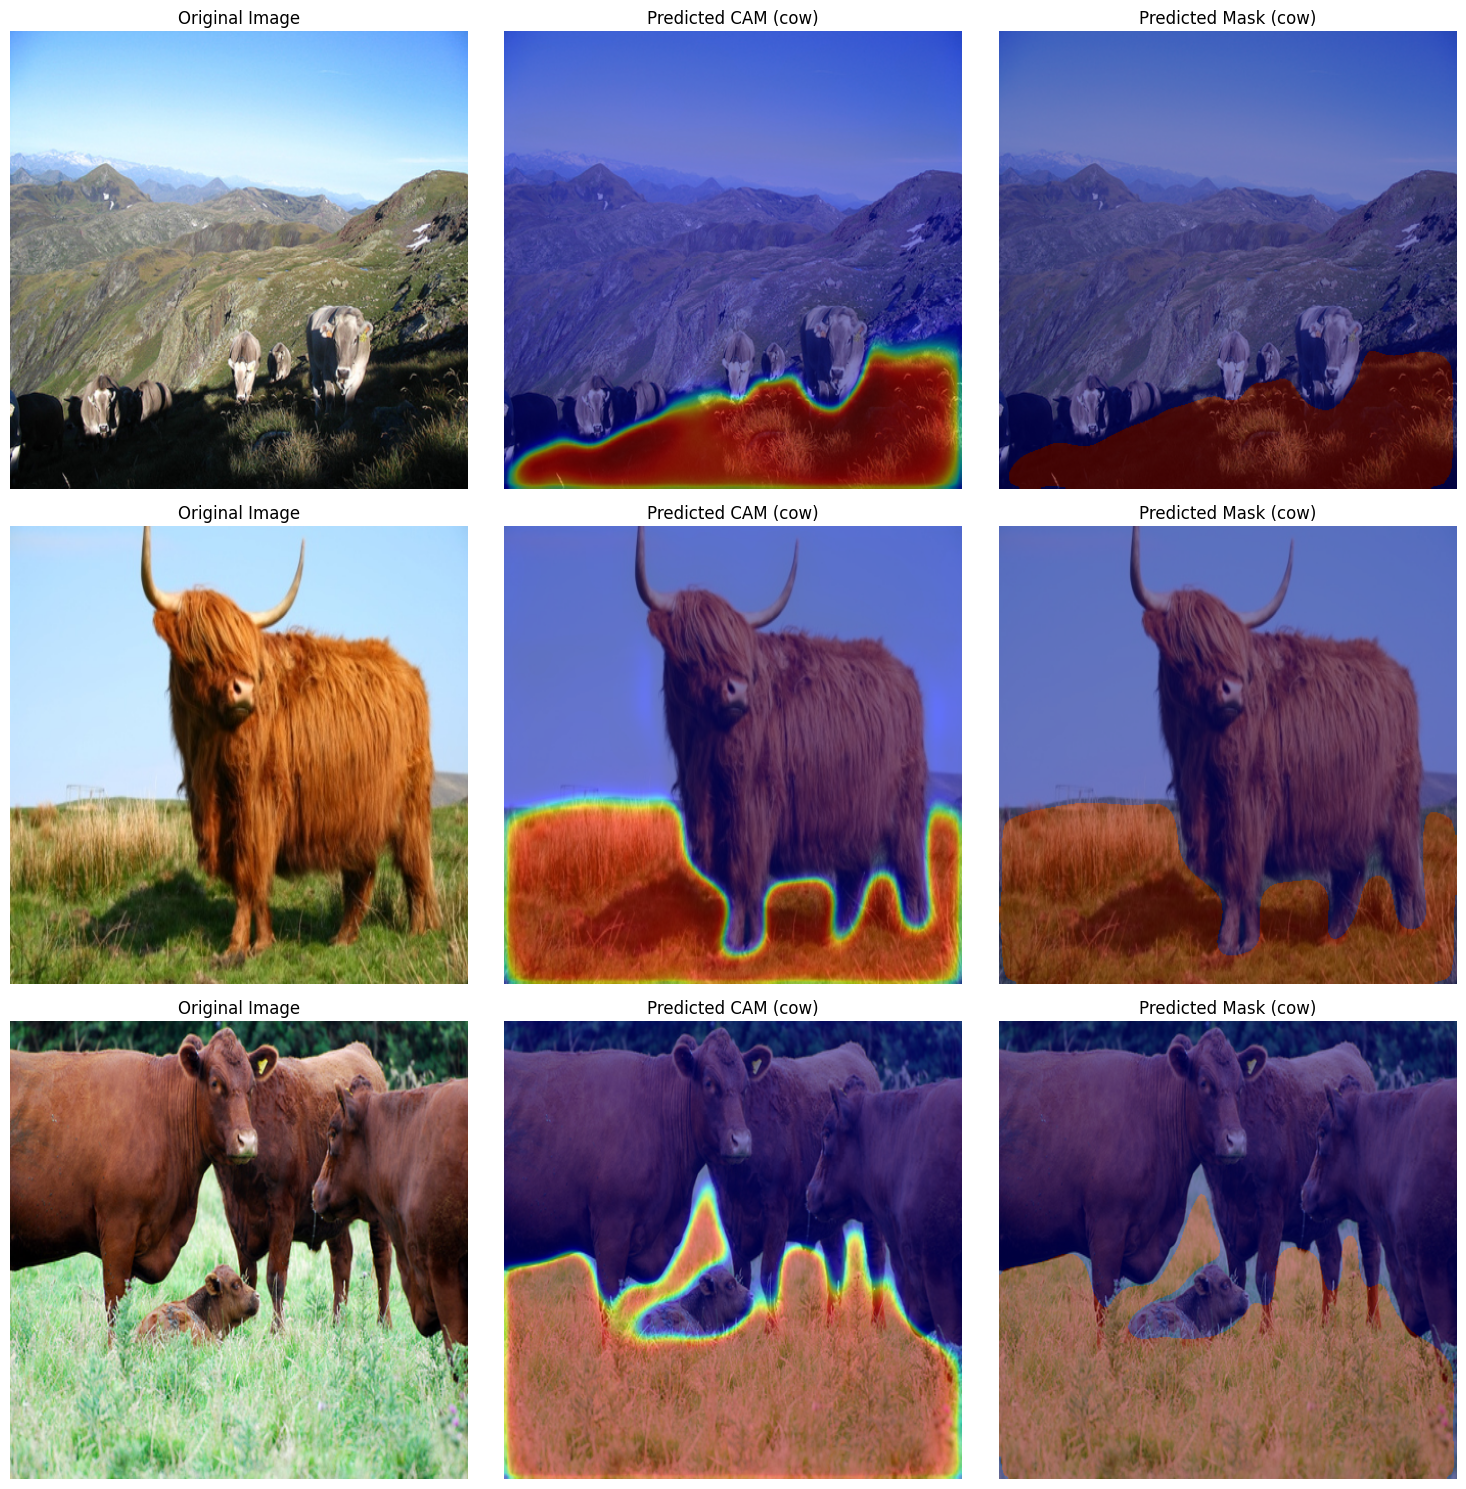

In [ ]:
def visualize_results(model, dataset, num_images=4, epoch=None, target_class=None):
    model.eval()

    c_target = None
    if target_class is not None:
        c_target = VOC_CLASSES.index(target_class) if isinstance(target_class, str) else target_class
        indices = []
        attempts = 0
        while len(indices) < num_images and attempts < 1000:
            idx = random.randint(0, len(dataset) - 1)
            _, _, label_vec = dataset[idx]
            if label_vec[c_target] > 0 and idx not in indices:
                indices.append(idx)
            attempts += 1
        num_images = len(indices)
        if num_images == 0:
            print(f"No images found for class '{target_class}'.")
            return
    else:
        indices = random.sample(range(len(dataset)), num_images)

    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    if num_images == 1:
        axes = [axes]
    if epoch is not None:
        fig.suptitle(f"Epoch {epoch} Results", fontsize=16)

    for idx, row in zip(indices, axes):
        _, img_t, label_vec = dataset[idx]
        with torch.no_grad():
            patch_tokens = dino_cache_tensor[idx].unsqueeze(0).float()
            grid_dim = int(patch_tokens.shape[1] ** 0.5)
            _, dense_logits = model(
                patch_tokens,
                grid_size=(grid_dim, grid_dim),
                target_size=(img_t.shape[1], img_t.shape[2]),
            )
            pred_probs = torch.sigmoid(dense_logits)[0].cpu()

        img_vis = img_t.clone()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_vis = img_vis * std + mean
        img_vis = img_vis.clamp(0, 1).permute(1, 2, 0).numpy()

        c_idx = c_target
        if c_idx is None:
            active_classes = torch.where(label_vec > 0)[0]
            c_idx = active_classes[0] if len(active_classes) > 0 else None

        row[0].imshow(img_vis)
        row[0].set_title("Original Image")
        row[0].axis('off')

        if c_idx is not None:
            class_name = VOC_CLASSES[c_idx]
            cam = pred_probs[c_idx].numpy()
            row[1].imshow(img_vis)
            row[1].imshow(cam, cmap='jet', alpha=0.5)
            row[1].set_title(f"Predicted CAM ({class_name})")
            row[1].axis('off')
            mask = (cam > 0.5).astype(float)
            row[2].imshow(img_vis)
            row[2].imshow(mask, cmap='jet', alpha=0.5)
            row[2].set_title(f"Predicted Mask ({class_name})")
            row[2].axis('off')
        else:
            row[1].axis('off')
            row[2].axis('off')

    plt.tight_layout()
    if epoch is not None:
        plt.subplots_adjust(top=0.95)
    plt.show()

visualize_results(model, voc_segmentation, num_images=3, target_class='cow')